### 1. Library Imports
We import core data manipulation libraries (`numpy`, `pandas`), visualization libraries (`matplotlib`, `seaborn`), and utilities from `scikit-learn` for fetching the dataset, feature preprocessing, train-test splitting, training linear/regularized models, and calculating model evaluation metrics.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    root_mean_squared_error, 
    r2_score
)

### 2. Loading the Dataset
We load the California Housing dataset using `fetch_california_housing(as_frame=True)` so we can work directly with a pandas DataFrame containing the descriptive features and the target variable.

In [3]:
dataset = fetch_california_housing(as_frame=True)

df = dataset.frame

print(df)

       MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  MedHouseVal
0      8.3252      41.0  6.984127  ...     37.88    -122.23        4.526
1      8.3014      21.0  6.238137  ...     37.86    -122.22        3.585
2      7.2574      52.0  8.288136  ...     37.85    -122.24        3.521
3      5.6431      52.0  5.817352  ...     37.85    -122.25        3.413
4      3.8462      52.0  6.281853  ...     37.85    -122.25        3.422
...       ...       ...       ...  ...       ...        ...          ...
20635  1.5603      25.0  5.045455  ...     39.48    -121.09        0.781
20636  2.5568      18.0  6.114035  ...     39.49    -121.21        0.771
20637  1.7000      17.0  5.205543  ...     39.43    -121.22        0.923
20638  1.8672      18.0  5.329513  ...     39.43    -121.32        0.847
20639  2.3886      16.0  5.254717  ...     39.37    -121.24        0.894

[20640 rows x 9 columns]


### 3. Inspecting the First and Last Rows
We display the first 5 and last 5 rows of our DataFrame using `.head()` and `.tail()` to visually inspect the data structure, values, and column names.

In [4]:
print(df.head())
print()
print(df.tail())

   MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127  ...     37.88    -122.23        4.526
1  8.3014      21.0  6.238137  ...     37.86    -122.22        3.585
2  7.2574      52.0  8.288136  ...     37.85    -122.24        3.521
3  5.6431      52.0  5.817352  ...     37.85    -122.25        3.413
4  3.8462      52.0  6.281853  ...     37.85    -122.25        3.422

[5 rows x 9 columns]

       MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  MedHouseVal
20635  1.5603      25.0  5.045455  ...     39.48    -121.09        0.781
20636  2.5568      18.0  6.114035  ...     39.49    -121.21        0.771
20637  1.7000      17.0  5.205543  ...     39.43    -121.22        0.923
20638  1.8672      18.0  5.329513  ...     39.43    -121.32        0.847
20639  2.3886      16.0  5.254717  ...     39.37    -121.24        0.894

[5 rows x 9 columns]


### 4. Checking Dataset Dimensions
We use `.shape` to determine the total number of records (rows) and attributes (columns) present in the dataset.

In [5]:
df.shape

(20640, 9)

### 5. Inspecting Column Metadata and Data Types
We call `.info()` to check data types (e.g., float64) and ensure there are no missing or null values in any column.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### 6. Summary Descriptive Statistics
We run `.describe()` to view key statistics (mean, standard deviation, min, max, percentiles). This helps us check the scale of features and detect extreme outlier values.

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### 7. Checking for Missing (Null) Values
We count null values per column using `.isnull().sum()` to verify if any imputation or missing-value handling is required.

In [8]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### 8. Checking for Duplicate Rows
We check for identical duplicate records in the dataset using `.duplicated().sum()` to make sure we don't train our model on redundant data.

In [9]:
df.duplicated().sum()

np.int64(0)

### 9. Exploratory Data Analysis (EDA) - Visualizations
We plot a 3x2 grid of visualizations to explore target skewness (and the hard cap at 5.0), feature linearity, multicollinearity, outliers, and spatial patterns (latitude/longitude mapping).

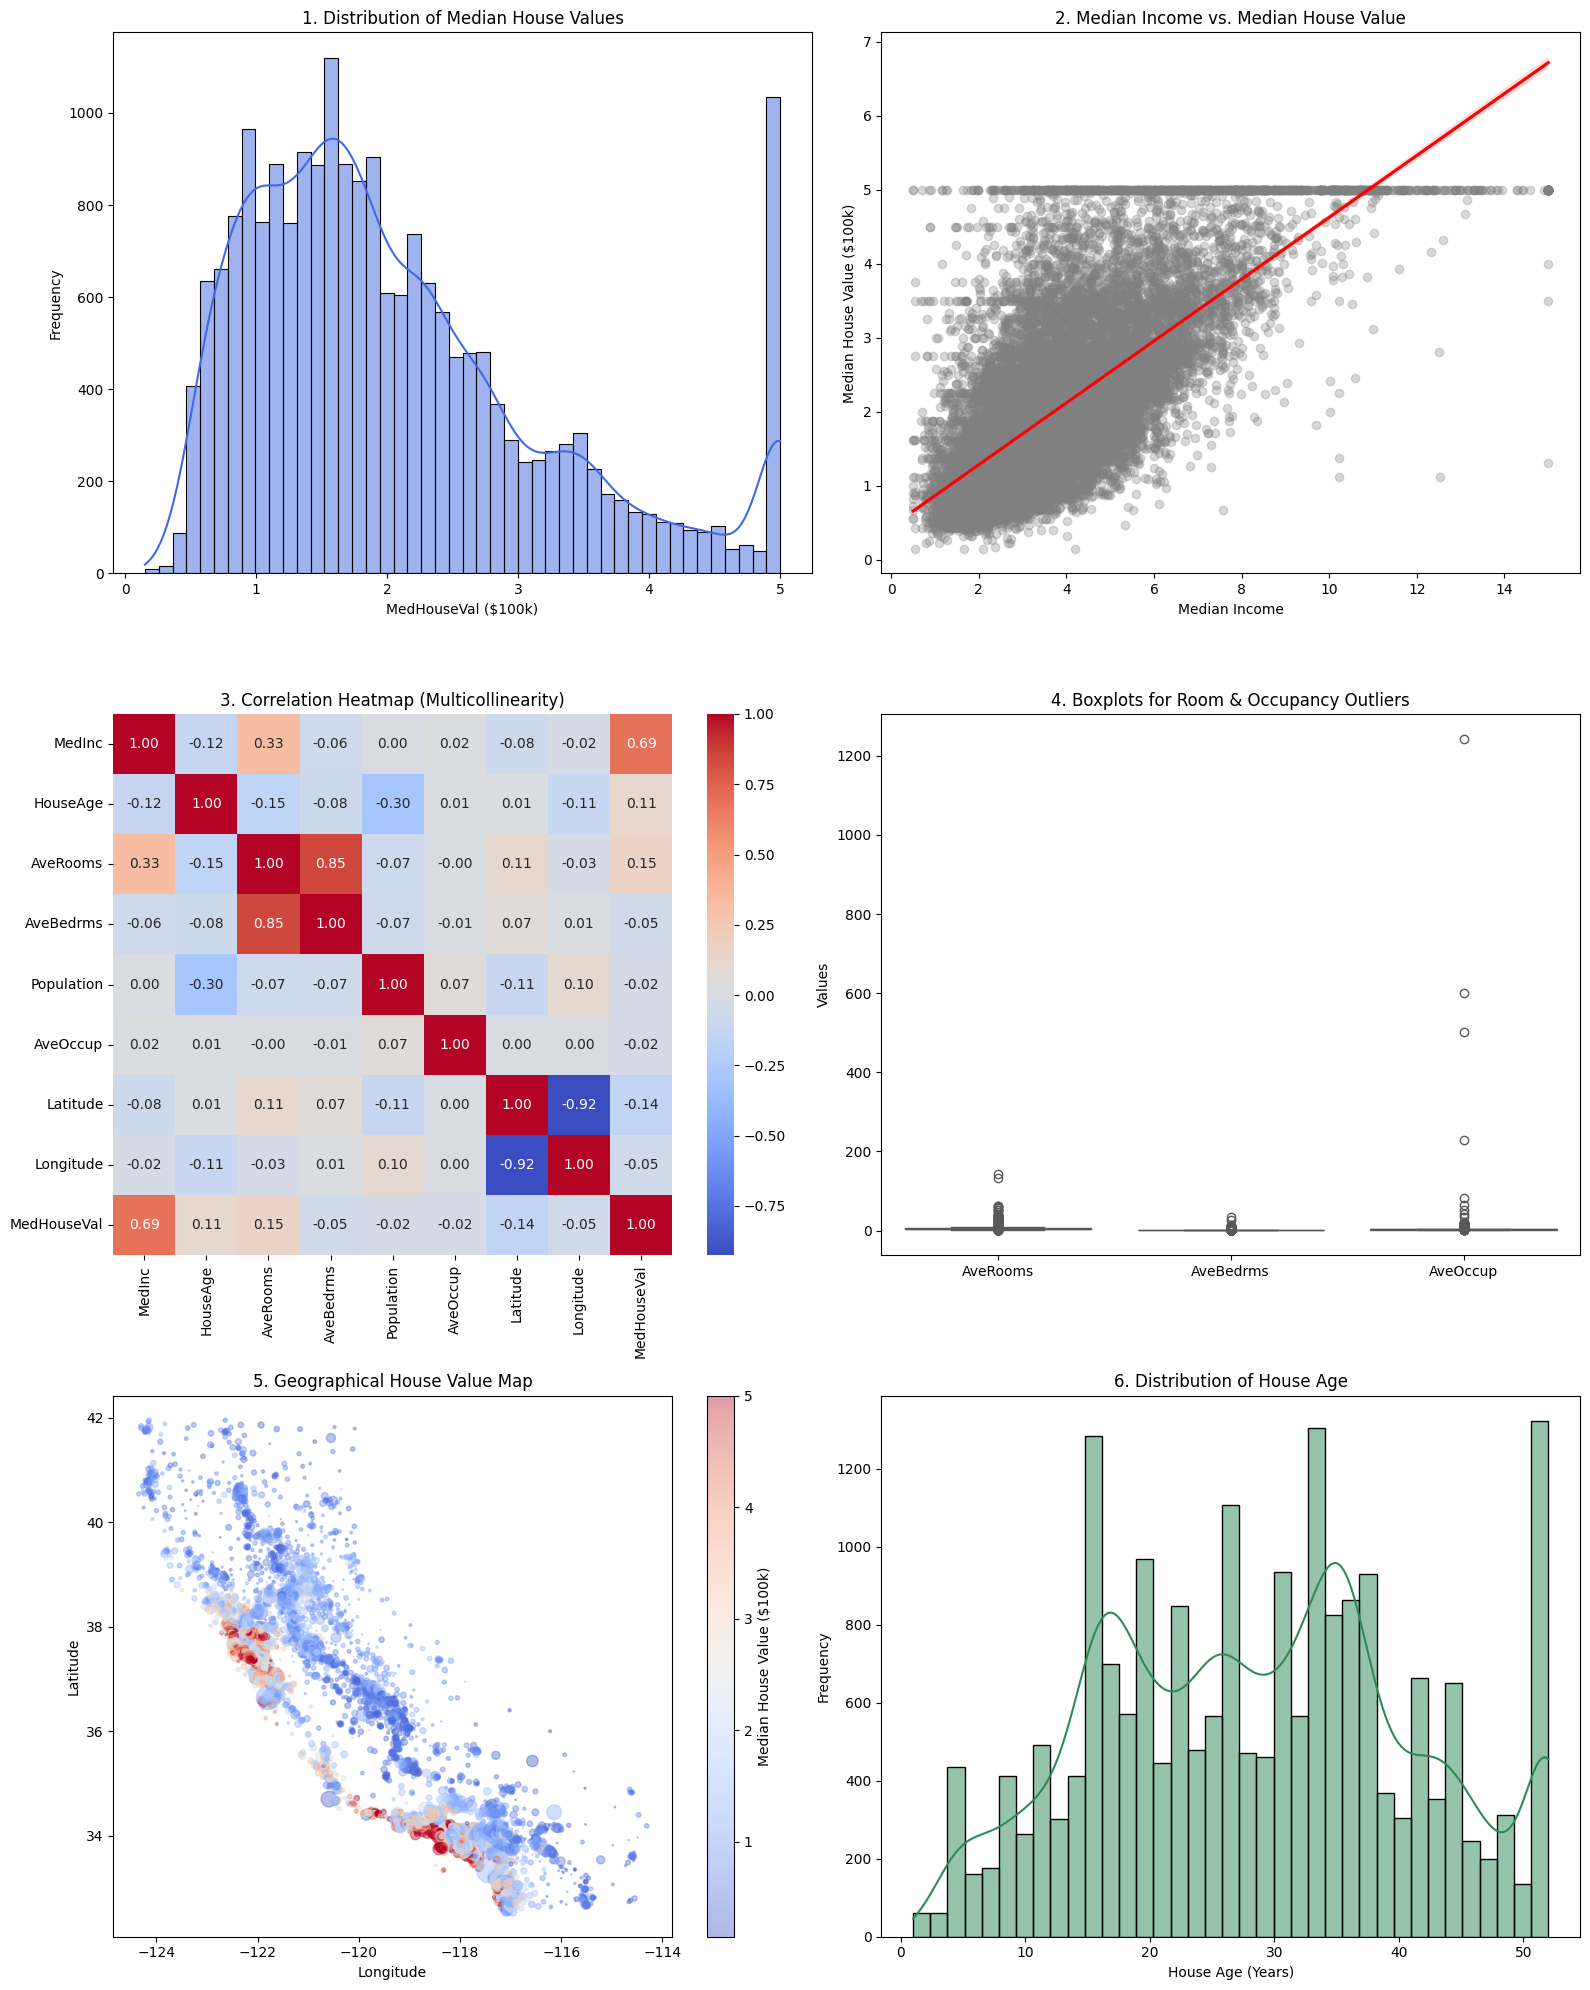

In [13]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(16, 20))


sns.histplot(df['MedHouseVal'], kde=True, ax=ax[0,0], color='royalblue')
ax[0, 0].set_title('1. Distribution of Median House Values', fontsize=12)
ax[0, 0].set_xlabel('MedHouseVal ($100k)')
ax[0, 0].set_ylabel('Frequency')


sns.regplot(data=df, x='MedInc', y='MedHouseVal', ax=ax[0, 1],
            scatter_kws={'alpha': 0.3, 'color': 'gray'}, line_kws={'color': 'red'})
ax[0, 1].set_title('2. Median Income vs. Median House Value', fontsize=12)
ax[0, 1].set_xlabel('Median Income')
ax[0, 1].set_ylabel('Median House Value ($100k)')


sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax[1, 0], cbar=True)
ax[1, 0].set_title('3. Correlation Heatmap (Multicollinearity)', fontsize=12)


sns.boxplot(data=df[['AveRooms', 'AveBedrms', 'AveOccup']], ax=ax[1, 1], palette='Set2')
ax[1, 1].set_title('4. Boxplots for Room & Occupancy Outliers', fontsize=12)
ax[1, 1].set_ylabel('Values')


sc = ax[2, 0].scatter(
    x=df['Longitude'], y=df['Latitude'], 
    c=df['MedHouseVal'], cmap='coolwarm', 
    s=df['Population']/100, alpha=0.4
)
fig.colorbar(sc, ax=ax[2, 0], label='Median House Value ($100k)')
ax[2, 0].set_title('5. Geographical House Value Map', fontsize=12)
ax[2, 0].set_xlabel('Longitude')
ax[2, 0].set_ylabel('Latitude')


sns.histplot(df['HouseAge'], kde=True, ax=ax[2, 1], color='seagreen')
ax[2, 1].set_title('6. Distribution of House Age', fontsize=12)
ax[2, 1].set_xlabel('House Age (Years)')
ax[2, 1].set_ylabel('Frequency')


plt.tight_layout()
plt.show()

### 10. Data Cleaning and Feature Engineering
Based on our EDA, we filter out extreme outliers and capped target values, and engineer `BedroomsPerRoom` to resolve the high correlation between `AveRooms` and `AveBedrms`.

In [51]:
df_clean = df[
    (df['AveRooms'] < 15) & 
    (df['AveBedrms'] < 5) & 
    (df['AveOccup'] < 6) & 
    (df['Population'] < 10000)
]

df_clean = df_clean[df_clean['MedHouseVal'] < 5.0]

df_clean['BedroomsPerRoom'] = df_clean['AveBedrms'] / df_clean['AveRooms']
df_clean = df_clean.drop(columns=['AveBedrms'])

print(df_clean.shape)

print(df_clean.columns)

(19411, 9)
Index(['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude',
       'Longitude', 'MedHouseVal', 'BedroomsPerRoom'],
      dtype='str')


### 11. Splitting Independent (X) and Dependent (y) Variables
We separate the target variable (`y`) from the features (`X`). We also drop the raw coordinates (`Latitude` and `Longitude`) because linear regression cannot model complex geographical clusters linearly.

In [23]:
X = df_clean.drop(["MedHouseVal", "Latitude", "Longitude"], axis=1)
y = df_clean["MedHouseVal"]

### 12. Train-Test Split
We split the dataset into an 80% training set (to fit our model) and a 20% test set (to evaluate its performance on unseen data).

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 13. Feature Scaling (Standardization)
We scale features using `StandardScaler` to have a mean of 0 and a standard deviation of 1. We fit the scaler on the training set only to prevent data leakage.

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 14. Training Baseline Linear Regression
We fit a standard Ordinary Least Squares (OLS) Linear Regression model to find the best linear relationships in the training set.

In [29]:
linReg_model = LinearRegression()

linReg_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 15. Making Predictions
We use our trained OLS model to predict house values for the scaled test set.

In [35]:
y_pred = linReg_model.predict(X_test_scaled)

print(y_pred)

[1.96860441 2.69890158 1.36490751 ... 1.55070789 0.79813506 1.22590926]


### 16. Baseline Model Evaluation
We calculate standard regression metrics (MSE, RMSE, MAE, and $R^2$) to evaluate the accuracy of our baseline model.

In [36]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"R^2 Score: {r2_score(y_test, y_pred)}")

Mean Squared Error: 0.397612229128321
Root Mean Squared Error: 0.630565007852736
Mean Absolute Error: 0.47817821859523424
R^2 Score: 0.584158508289138


### 17. Training Ridge Regression (L2 Regularization)
We fit a Ridge regression model, which adds an L2 penalty (squared weights) to shrink coefficients and prevent overfitting.

In [40]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

y_pred_ridge

array([1.96864261, 2.69883208, 1.36498963, ..., 1.55077215, 0.79827532,
       1.22593681], shape=(3883,))

### 18. Ridge Model Evaluation
We evaluate the performance of our Ridge model on the test set.

In [46]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_ridge)}")
print(f"Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred_ridge)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_ridge)}")
print(f"R^2 Score: {r2_score(y_test, y_pred_ridge)}")

Mean Squared Error: 0.3976178576354811
Root Mean Squared Error: 0.6305694709034692
Mean Absolute Error: 0.4781861351826188
R^2 Score: 0.5841526217327343


### 19. Training Lasso Regression (L1 Regularization)
We fit a Lasso regression model, which adds an L1 penalty (absolute weights) to perform automatic feature selection by shrinking coefficients to exactly zero.

In [44]:
lasso_model = Lasso(alpha=0.01)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

y_pred_lasso

array([1.98418552, 2.66614519, 1.38144039, ..., 1.57267243, 0.85439523,
       1.22862521], shape=(3883,))

### 20. Lasso Model Evaluation
We evaluate our Lasso model on the test set.

In [43]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lasso)}")
print(f"Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred_lasso)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_lasso)}")
print(f"R^2 Score: {r2_score(y_test, y_pred_lasso)}")

Mean Squared Error: 0.3999431133169916
Root Mean Squared Error: 0.6324105575628791
Mean Absolute Error: 0.4803703446474523
R^2 Score: 0.581720760435791


**Note** :- The reason Ridge and Lasso are giving almost the exact same results as standard Linear Regression is because your model is not overfitting.

### 21. High-Dimensional Model Comparison (Polynomial Degree 3)
We generate 164 cubic and interaction features using `PolynomialFeatures(degree=3)` and compare Standard, Ridge, and Lasso models. Lasso performs best by setting noisy/unnecessary features to exactly zero.

Warning :-
If we increase the degree of the polynomial (e.g., to degree=3 or degree=4), two major things will happen: a feature explosion and a high risk of extreme overfitting.

1. **Feature Explosion (The Curse of Dimensionality)** :
The number of features generated by PolynomialFeatures grows exponentially with the degree.

```
With 8 features:
Degree 1 (Linear): 8 features
Degree 2: 44 features
Degree 3: 164 features
Degree 4: 494 features
Degree 5: 1,286 features
```
As the number of features increases, the model requires much more memory and computational power to train.

2. **Extreme Overfitting (High Variance)** :
With higher degrees, the regression model is no longer fitting a line; it is fitting extremely complex, "wiggly" curves.

The model will fit the training data almost perfectly (training score will go up).
However, on the test set, these wiggly curves will behave wildly, and your test score ($R^2$) will drop dramatically (often becoming highly negative).

In [50]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
print("Standard Linear Regression (Poly) R^2:", r2_score(y_test, lr_poly.predict(X_test_poly)))

ridge_poly = Ridge(alpha=10.0)
ridge_poly.fit(X_train_poly, y_train)
print("Ridge (Poly) R^2:", r2_score(y_test, ridge_poly.predict(X_test_poly)))

lasso_poly = Lasso(alpha=0.001, max_iter=10000)
lasso_poly.fit(X_train_poly, y_train)
print("Lasso (Poly) R^2:", r2_score(y_test, lasso_poly.predict(X_test_poly)))

Standard Linear Regression (Poly) R^2: 0.6295174700710726
Ridge (Poly) R^2: 0.6297868244605538
Lasso (Poly) R^2: 0.6315075717383727


### 22. Summary and Key Findings

This notebook demonstrated the implementation of Linear, Ridge, and Lasso Regression models to predict median housing values on the California Housing dataset.

### Data Analysis Key Findings
* **Baseline Performance**: The baseline Ordinary Least Squares (OLS) Linear Regression model achieved a test $R^2$ score of **58.42%** (with an RMSE of **0.6306** and MAE of **0.4782**).
* **Regularization Impact on Low Dimensions**: On the standard features (no polynomial features), Ridge and Lasso yielded almost identical test $R^2$ scores to the baseline. This indicates that the baseline model was not experiencing overfitting at low dimensions.
* **Benefits of Feature Expansion (Polynomials)**: 
  * Generating 164 cubic and interaction features (`PolynomialFeatures(degree=3)`) significantly increased model representation capacity, boosting the standard Linear Regression $R^2$ to **62.95%**.
* **Regularization on High-Dimensional Data**:
  * With 164 features, **Lasso Regression (L1)** outperformed standard and Ridge models by achieving the highest test $R^2$ score of **63.15%**. This is because Lasso sets coefficients of uninformative/noisy features to exactly zero, performing automatic feature selection and reducing variance.

### Insights or Next Steps
* **Investigate Non-Linear Models**: While polynomial features improved the linear model's score, housing values often contain complex non-linear spatial dependencies. Running a tree-based ensemble model (such as Random Forest or XGBoost) on the coordinates (`Latitude`, `Longitude`) would likely yield higher predictive performance.
* **Optimize Lasso Alpha**: Further hyperparameter tuning of the regularization strength ($\alpha$) for Lasso and Ridge on the polynomial dataset using cross-validation could squeeze out minor performance gains.